# Validation and Performance of the 137 MHz MWA AEE Model

This notebook compares the `mwa_jaxbeam` 137 MHz Average Embedded Element (AEE)
beam model against the reference implementation in `pyuvdata`, and benchmarks
JAX-compiled forward and gradient evaluations.

1. a numerical comparison at representative sky directions;
2. a full visible-hemisphere HEALPix comparison; and
3. performance benchmarks for inference-oriented workloads.


In [1]:
import time
from pathlib import Path

import cmasher as cmr
import healpy as hp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from pyuvdata import UVBeam

from mwa_jaxbeam import jones, power

FREQUENCY_HZ = 137e6
NSIDE = 32
POWER_FLOOR_DB = -60.0

# Resolve reference-data paths whether the notebook is run from the repository
# root or from the notebooks directory.
cwd = Path.cwd()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd
jmatrix_path = repo_root / "data" / "Jmatrix.fits"
zmatrix_path = repo_root / "data" / "ZMatrix.fits"

for path in (jmatrix_path, zmatrix_path):
    if not path.exists():
        raise FileNotFoundError(f"Reference file not found: {path}")

beam_cmap = LinearSegmentedColormap.from_list(
    "pride",
    cmr.pride(np.linspace(0.1, 0.8, 256)),
)
beam_cmap.set_under("white")

print(f"JAX backend: {jax.default_backend()}")
print(f"JAX devices: {jax.devices()}")

JAX backend: cpu
JAX devices: [CpuDevice(id=0)]


### Coordinate conventions

Several coordinate conventions are involved in the implementation and
validation of the beam model. They are summarized here to avoid ambiguity.

#### Local ENU coordinates

Throughout `mwa_jaxbeam` we use a local East–North–Up (ENU) Cartesian frame,

$$
\hat{\mathbf{s}}
=
(E,\,N,\,U),
$$

with azimuth measured **eastward from North**,

$$
\mathrm{az}=0^\circ
\rightarrow
\mathrm{North},
\qquad
90^\circ
\rightarrow
\mathrm{East},
\qquad
180^\circ
\rightarrow
\mathrm{South},
\qquad
270^\circ
\rightarrow
\mathrm{West}.
$$

The corresponding unit direction vector is

$$
\hat{\mathbf{s}}
=
\left(
\sin\theta\sin\mathrm{az},
\;
\sin\theta\cos\mathrm{az},
\;
\cos\theta
\right),
$$

where $\theta$ is the zenith angle.

#### pyuvdata convention

The underlying FEKO AEE beam model, and therefore `pyuvdata`, instead measures
azimuth **eastward from East**,

$$
\phi=0^\circ
\rightarrow
\mathrm{East},
\qquad
90^\circ
\rightarrow
\mathrm{North}.
$$

The two conventions differ only by a $90^\circ$ rotation,

$$
\phi
=
\left(
\frac{\pi}{2}
-
\mathrm{az}
\right)
\bmod 2\pi.
$$

This conversion is applied whenever the JAX implementation is compared with the
reference `pyuvdata` model.

#### HEALPix convention

HEALPix adopts the standard spherical-coordinate convention

$$
\mathbf{r}
=
(
\sin\theta\cos\phi,\,
\sin\theta\sin\phi,\,
\cos\theta
),
$$

where $\theta$ is the colatitude (zenith angle) and $\phi$ is longitude.

When interpreted in the local ENU frame,

$$
+x \equiv \mathrm{East},
\qquad
+y \equiv \mathrm{North},
\qquad
+z \equiv \mathrm{Up},
$$

so the HEALPix longitude $\phi$ is identical to the azimuth convention used by
`pyuvdata`. Consequently, HEALPix pixel indices are generated from the JAX
azimuths using

$$
\phi_{\rm HP}
=
\left(
\frac{\pi}{2}
-
\mathrm{az}
\right)
\bmod 2\pi.
$$

#### Plot orientation

All HEALPix maps in this notebook are displayed using

```python
hp.orthview(
    ...,
    rot=(0, 90, -90),
    flip="geo",
    half_sky=True,
)
```

which produces the familiar local-sky orientation

```text
          North
West                 East
          South
```

This plotting convention was verified using a synthetic HEALPix map with
isolated pixels placed at the four cardinal directions.

In [2]:
def azimuth_ne_to_en(az_rad):
    """
    Convert azimuth from North-through-East to East-through-North.

    Parameters
    ----------
    az_rad
        Azimuth in radians with

        - 0 at North,
        - pi / 2 at East,
        - pi at South,
        - 3 pi / 2 at West.

    Returns
    -------
    az_en_rad
        Azimuth in radians with

        - 0 at East,
        - pi / 2 at North,
        - pi at West,
        - 3 pi / 2 at South.

    Notes
    -----
    This is the convention used by the native FEKO AEE data, pyuvdata,
    and HEALPix longitude when the Cartesian axes are interpreted as

        x = East
        y = North
        z = Up

    This function converts from our `mwa_jaxbeam` coordinated to pyuvdata
    and HEALPix conventions.
    """
    return np.mod(
        np.pi / 2.0 - np.asarray(az_rad),
        2.0 * np.pi,
    )


def azimuth_en_to_ne(az_rad):
    """
    Convert azimuth from East-through-North to North-through-East.

    Parameters
    ----------
    az_rad
        Azimuth in radians with

        - 0 at East,
        - pi / 2 at North,
        - pi at West,
        - 3 pi / 2 at South.

    Returns
    -------
    az_ne_rad
        Azimuth in radians with

        - 0 at North,
        - pi / 2 at East,
        - pi at South,
        - 3 pi / 2 at West.

    Notes
    -----
    This is the inverse of :func:`azimuth_ne_to_en`.

    The transformation is self-inverse modulo 2 pi, so both functions use
    the same algebraic expression. Separate names are retained to make the
    direction of each coordinate conversion explicit at the call site.

    This function converts from pyuvdata and HEALPix conventions to our
    `mwa_jaxbeam` coordinates
    """
    return np.mod(
        np.pi / 2.0 - np.asarray(az_rad),
        2.0 * np.pi,
    )

In [3]:
def interpolate_pyuvdata_efield(beam, az_rad, za_rad):
    """Interpolate the pyuvdata E-field at 137 MHz."""
    result = beam.interp(
        az_array=np.asarray(az_rad),
        za_array=np.asarray(za_rad),
        freq_array=np.array([FREQUENCY_HZ]),
        return_basis_vector=False,
        check_azza_domain=True,
    )
    efield = result[0] if isinstance(result, tuple) else result
    return np.asarray(efield)[:, :, 0, :]


def efield_to_power(efield):
    """Convert an E-field Jones response to XX and YY power."""
    return np.sum(np.abs(efield) ** 2, axis=0)


def power_to_db(values, floor_db=POWER_FLOOR_DB):
    """Convert linear power to decibels with a plotting floor."""
    floor = 10.0 ** (floor_db / 10.0)
    return 10.0 * np.log10(np.maximum(values, floor))

## Load the pyuvdata reference model

In [4]:
aee_beam = UVBeam()

aee_beam.read_mwa_beam(
    jmatrix_path,
    zfile=zmatrix_path,
    delays=np.zeros((2, 16), dtype=int),
    amplitudes=np.ones((2, 16), dtype=float),
    include_cross_feed_coupling=True,
)

max_za_rad = float(np.max(aee_beam.axis2_array))

print(f"Beam type: {aee_beam.beam_type}")
print(f"Coordinate system: {aee_beam.pixel_coordinate_system}")
print(f"Frequency range: {aee_beam.freq_array[[0, -1]] / 1e6} MHz")
print(f"Maximum zenith angle: {np.rad2deg(max_za_rad):.1f} deg")

Beam type: efield
Coordinate system: az_za
Frequency range: [ 72.96 239.36] MHz
Maximum zenith angle: 90.0 deg


In [5]:
# Normalize each feed by its exact-zenith response.
pyuv_zenith_efield = interpolate_pyuvdata_efield(
    aee_beam,
    az_rad=np.array([np.pi / 2.0]),
    za_rad=np.array([0.0]),
)
pyuv_zenith_power = efield_to_power(pyuv_zenith_efield)[:, 0]

print("pyuvdata zenith power:", pyuv_zenith_power)

pyuvdata zenith power: [1.84209469 1.84209248]


## Cardinal-direction comparison

In [6]:
direction_names = ("North", "East", "South", "West")
az_jax = np.deg2rad([0.0, 90.0, 180.0, 270.0])
za_rad = np.deg2rad(np.full(4, 30.0))

jax_cardinal_power = np.asarray(
    power(
        az_rad=az_jax,
        za_rad=za_rad,
        normalize=True,
    )
)

pyuv_cardinal_efield = interpolate_pyuvdata_efield(
    aee_beam,
    az_rad=azimuth_ne_to_en(az_jax),
    za_rad=za_rad,
)
pyuv_cardinal_power = efield_to_power(pyuv_cardinal_efield) / pyuv_zenith_power[:, np.newaxis]

print(f"{'Feed':<5} {'Direction':<10} {'JAX':>12} {'pyuvdata':>12} {'Residual [dB]':>16}")
print("-" * 61)

for feed, feed_name in enumerate(("XX", "YY")):
    for index, direction in enumerate(direction_names):
        residual_db = 10.0 * np.log10(jax_cardinal_power[feed, index] / pyuv_cardinal_power[feed, index])
        print(
            f"{feed_name:<5} {direction:<10} "
            f"{jax_cardinal_power[feed, index]:12.6f} "
            f"{pyuv_cardinal_power[feed, index]:12.6f} "
            f"{residual_db:16.4f}"
        )

Feed  Direction           JAX     pyuvdata    Residual [dB]
-------------------------------------------------------------
XX    North          0.000076     0.000076          -0.0070
XX    East           0.000094     0.000094           0.0042
XX    South          0.000076     0.000076          -0.0065
XX    West           0.000094     0.000094           0.0043
YY    North          0.000094     0.000094           0.0039
YY    East           0.000076     0.000076          -0.0067
YY    South          0.000094     0.000094           0.0035
YY    West           0.000076     0.000076          -0.0070


## Full visible-hemisphere comparison

Both implementations are evaluated at the same $N_{\mathrm{side}}=32$
HEALPix pixel centres. The residual is

$$
\Delta P =
10\log_{10}P_{\mathrm{JAX}}
-
10\log_{10}P_{\mathrm{pyuvdata}}.
$$


In [7]:
npix = hp.nside2npix(NSIDE)
pixel_indices = np.arange(npix)
za_hpx, phi_hpx = hp.pix2ang(NSIDE, pixel_indices)

# HEALPix phi is East-through-North. Convert it to the package convention.
az_jax_hpx = azimuth_en_to_ne(phi_hpx)
az_pyuvdata_hpx = azimuth_ne_to_en(az_jax_hpx)

visible = za_hpx <= max_za_rad
n_visible = int(np.count_nonzero(visible))

print(f"HEALPix pixels: {npix}")
print(f"Compared pixels: {n_visible}")

HEALPix pixels: 12288
Compared pixels: 6208


In [8]:
jax_power_hpx = np.full((2, npix), np.nan, dtype=float)
jax_power_hpx[:, visible] = np.asarray(
    power(
        az_rad=az_jax_hpx[visible],
        za_rad=za_hpx[visible],
        normalize=True,
    )
)

pyuv_efield_visible = interpolate_pyuvdata_efield(
    aee_beam,
    az_rad=az_pyuvdata_hpx[visible],
    za_rad=za_hpx[visible],
)
pyuv_power_visible = efield_to_power(pyuv_efield_visible) / pyuv_zenith_power[:, np.newaxis]

pyuv_power_hpx = np.full((2, npix), np.nan, dtype=float)
pyuv_power_hpx[:, visible] = pyuv_power_visible

jax_power_db = power_to_db(jax_power_hpx)
pyuv_power_db = power_to_db(pyuv_power_hpx)

residual_db = 10.0 * np.log10(
    np.maximum(jax_power_hpx, np.finfo(float).tiny) / np.maximum(pyuv_power_hpx, np.finfo(float).tiny)
)

residual_linear = jax_power_hpx - pyuv_power_hpx

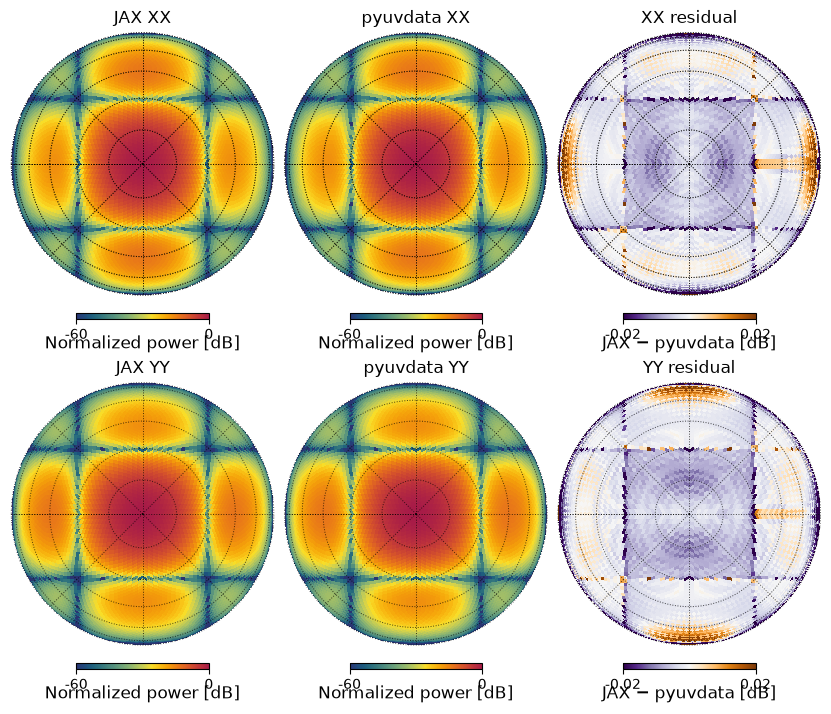

In [9]:
def as_healpix_map(values):
    """Replace non-finite values with HEALPix's unseen sentinel."""
    result = np.full(values.shape, hp.UNSEEN, dtype=float)
    finite = np.isfinite(values)
    result[finite] = values[finite]
    return result


jax_maps = as_healpix_map(jax_power_db)
pyuv_maps = as_healpix_map(pyuv_power_db)
residual_maps = as_healpix_map(residual_db)

fig = plt.figure(figsize=(8.2, 7.0))

beam_kwargs = {
    "rot": (0, 90, -90),
    "half_sky": True,
    "flip": "geo",
    "fig": fig,
    "min": POWER_FLOOR_DB,
    "max": 0.0,
    "unit": "\n\nNormalized power [dB]",
    "badcolor": "whitesmoke",
    "cmap": beam_cmap,
}
residual_kwargs = {
    "rot": (0, 90, -90),
    "half_sky": True,
    "flip": "geo",
    "fig": fig,
    "min": -0.02,
    "max": 0.02,
    "unit": "\n\nJAX − pyuvdata [dB]",
    "cmap": "PuOr_r",
}

for row, feed_name in enumerate(("XX", "YY")):
    hp.orthview(
        jax_maps[row],
        sub=(2, 3, 1 + 3 * row),
        title=f"JAX {feed_name}",
        **beam_kwargs,
    )
    hp.orthview(
        pyuv_maps[row],
        sub=(2, 3, 2 + 3 * row),
        title=f"pyuvdata {feed_name}",
        **beam_kwargs,
    )
    hp.orthview(
        residual_maps[row],
        sub=(2, 3, 3 + 3 * row),
        title=f"{feed_name} residual",
        **residual_kwargs,
    )

    hp.graticule(dpar=15, dmer=45, ls=":", lw=0.7, alpha=0.7)

plt.show()

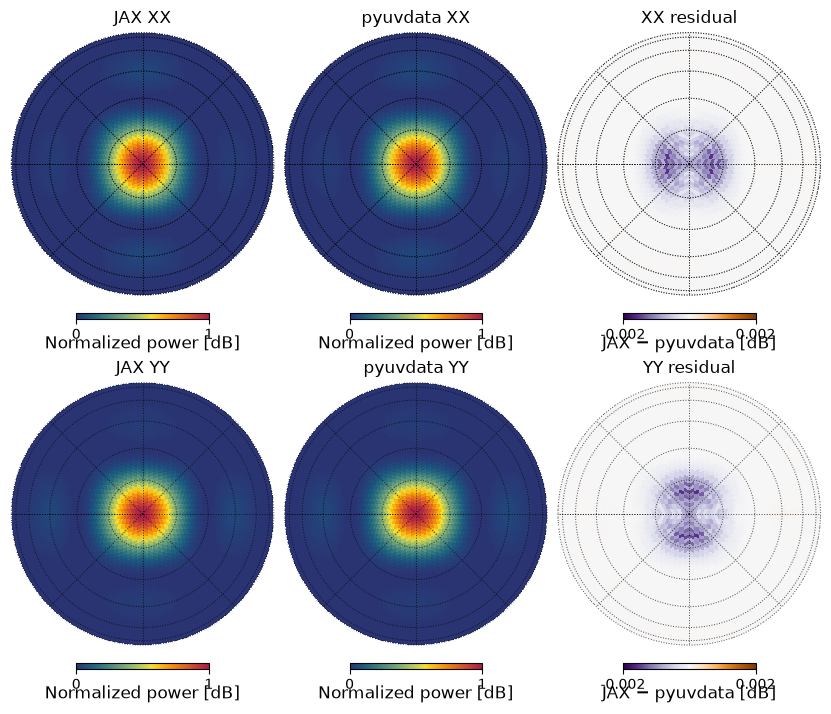

In [10]:
jax_linear_maps = as_healpix_map(jax_power_hpx)
pyuv_linear_maps = as_healpix_map(pyuv_power_hpx)
residual_linear_maps = as_healpix_map(residual_linear)

fig = plt.figure(figsize=(8.2, 7.0))

beam_kwargs = {
    "rot": (0, 90, -90),
    "half_sky": True,
    "flip": "geo",
    "fig": fig,
    "min": 0,
    "max": 1,
    "unit": "\n\nNormalized power [dB]",
    "badcolor": "whitesmoke",
    "cmap": beam_cmap,
}
residual_kwargs = {
    "rot": (0, 90, -90),
    "half_sky": True,
    "flip": "geo",
    "fig": fig,
    "min": -0.002,
    "max": 0.002,
    "unit": "\n\nJAX − pyuvdata [dB]",
    "cmap": "PuOr_r",
}

for row, feed_name in enumerate(("XX", "YY")):
    hp.orthview(
        jax_linear_maps[row],
        sub=(2, 3, 1 + 3 * row),
        title=f"JAX {feed_name}",
        **beam_kwargs,
    )
    hp.orthview(
        pyuv_linear_maps[row],
        sub=(2, 3, 2 + 3 * row),
        title=f"pyuvdata {feed_name}",
        **beam_kwargs,
    )
    hp.orthview(
        residual_linear_maps[row],
        sub=(2, 3, 3 + 3 * row),
        title=f"{feed_name} residual",
        **residual_kwargs,
    )

    hp.graticule(dpar=15, dmer=45, ls=":", lw=0.7, alpha=0.7)

plt.show()

### Residual statistics

In [11]:
comparison_mask = visible[np.newaxis, :] & (jax_power_db > POWER_FLOOR_DB) & (pyuv_power_db > POWER_FLOOR_DB)

print(f"{'Feed':<5} {'N':>8} {'Mean [dB]':>12} {'Std [dB]':>12} {'RMS [dB]':>12} {'Max |Δ| [dB]':>14}")
print("-" * 70)

for feed, feed_name in enumerate(("XX", "YY")):
    values = residual_db[feed, comparison_mask[feed]]
    print(
        f"{feed_name:<5} {values.size:8d} "
        f"{np.mean(values):12.4f} "
        f"{np.std(values):12.4f} "
        f"{np.sqrt(np.mean(values**2)):12.4f} "
        f"{np.max(np.abs(values)):14.4f}"
    )

Feed         N    Mean [dB]     Std [dB]     RMS [dB]   Max |Δ| [dB]
----------------------------------------------------------------------
XX        5682      -0.0063       0.0199       0.0209         0.2721
YY        5682      -0.0064       0.0197       0.0207         0.2722


### Funky complex dipoles

In [12]:
excitations = np.ones((2, 16), dtype=np.complex64)

excitations[0, 0] = 1 + 1j  # first X dipole
excitations[1, 0] = 1 - 1j  # last Y dipole

jax_power_hpx[:, visible] = np.asarray(
    power(
        az_rad=az_jax_hpx[visible],
        za_rad=za_hpx[visible],
        excitations=excitations,
        normalize=True,
    )
)

In [13]:
jax_power_hpx = np.full((2, npix), np.nan, dtype=float)
jax_power_hpx[:, visible] = np.asarray(
    power(
        az_rad=az_jax_hpx[visible],
        za_rad=za_hpx[visible],
        excitations=excitations,
        normalize=True,
    )
)

jax_power_db = power_to_db(jax_power_hpx)

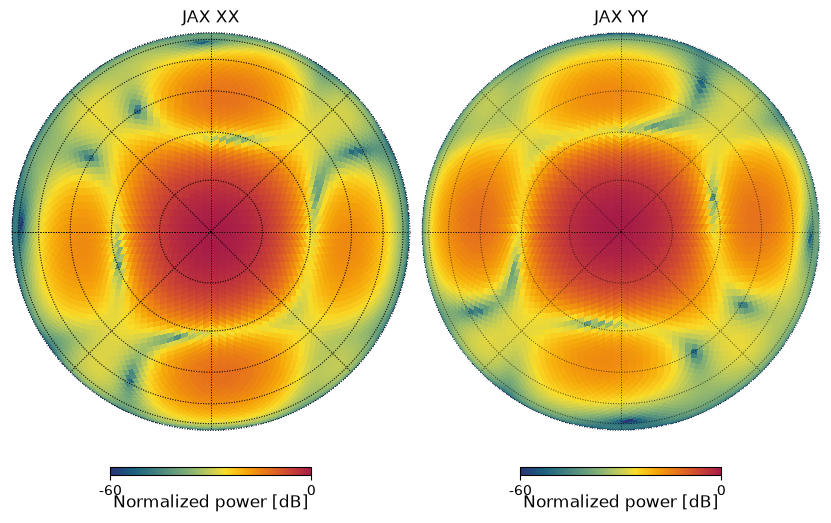

In [14]:
jax_maps = as_healpix_map(jax_power_db)
pyuv_maps = as_healpix_map(pyuv_power_db)
residual_maps = as_healpix_map(residual_db)

fig = plt.figure(figsize=(8.2, 7.0))

beam_kwargs = {
    "rot": (0, 90, -90),
    "half_sky": True,
    "flip": "geo",
    "fig": fig,
    "min": POWER_FLOOR_DB,
    "max": 0.0,
    "unit": "\n\nNormalized power [dB]",
    "badcolor": "whitesmoke",
    "cmap": beam_cmap,
}

for col, feed_name in enumerate(("XX", "YY")):
    hp.orthview(
        jax_maps[col],
        sub=(1, 2, 1 + col),
        title=f"JAX {feed_name}",
        **beam_kwargs,
    )
    hp.graticule(dpar=15, dmer=45, ls=":", lw=0.7, alpha=0.7)

plt.show()

## Performance benchmarks

The first call includes JAX tracing and compilation. Subsequent timings measure
compiled execution. Results are hardware- and backend-dependent.


In [15]:
MAX_BENCHMARK_DIRECTIONS = 12_288
BENCHMARK_SIZES = (48, 192, 768, 3_072, 6_144, 12_288)

# Deterministic directions distributed over the visible hemisphere.
index = np.arange(MAX_BENCHMARK_DIRECTIONS)
golden_angle = np.pi * (3.0 - np.sqrt(5.0))
az_benchmark = jnp.asarray(np.mod(index * golden_angle, 2.0 * np.pi))
za_benchmark = jnp.asarray(np.arccos(1.0 - (index + 0.5) / MAX_BENCHMARK_DIRECTIONS))

excitations = jnp.ones((2, 16), dtype=jnp.complex64)
jones_jit = jax.jit(jones)


def time_compiled(function, *args, iterations):
    """Return mean wall-clock time for an already-compiled JAX function."""
    result = function(*args)
    jax.block_until_ready(result)

    start = time.perf_counter()
    for _ in range(iterations):
        result = function(*args)
    jax.block_until_ready(result)

    return (time.perf_counter() - start) / iterations

### Forward Jones evaluation

In [16]:
start = time.perf_counter()
compiled_result = jones_jit(
    az_benchmark[:6_144],
    za_benchmark[:6_144],
    excitations,
)
jax.block_until_ready(compiled_result)
forward_compile_time = time.perf_counter() - start

forward_time = time_compiled(
    jones_jit,
    az_benchmark[:6_144],
    za_benchmark[:6_144],
    excitations,
    iterations=10_000,
)

print(f"Compilation: {forward_compile_time:.3f} s")
print(f"Compiled evaluation: {forward_time * 1e3:.3f} ms")
print(f"Throughput: {1.0 / forward_time:.1f} evaluations/s")

Compilation: 0.137 s
Compiled evaluation: 0.500 ms
Throughput: 1998.4 evaluations/s


In [17]:
print(f"{'Directions':>12} {'Time [ms]':>12} {'Time/direction [μs]':>22}")
print("-" * 50)

for size in BENCHMARK_SIZES:
    elapsed = time_compiled(
        jones_jit,
        az_benchmark[:size],
        za_benchmark[:size],
        excitations,
        iterations=200,
    )
    print(f"{size:12d} {elapsed * 1e3:12.3f} {elapsed / size * 1e6:22.3f}")

  Directions    Time [ms]    Time/direction [μs]
--------------------------------------------------
          48        0.041                  0.850
         192        0.054                  0.283
         768        0.122                  0.159
        3072        0.335                  0.109
        6144        0.496                  0.081
       12288        0.864                  0.070


### Loss and gradient evaluation

In [18]:
def loss(excitations, az_rad, za_rad):
    """Synthetic inference loss used only for benchmarking autodiff."""
    beam = jones(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=excitations,
    )
    xx_power = jnp.abs(beam[0, 0]) ** 2
    target = jnp.ones_like(xx_power)
    return jnp.mean((xx_power - target) ** 2)


loss_and_grad = jax.jit(jax.value_and_grad(loss))

start = time.perf_counter()
compiled_loss = loss_and_grad(
    excitations,
    az_benchmark[:6_144],
    za_benchmark[:6_144],
)
jax.block_until_ready(compiled_loss)
gradient_compile_time = time.perf_counter() - start

gradient_time = time_compiled(
    loss_and_grad,
    excitations,
    az_benchmark[:6_144],
    za_benchmark[:6_144],
    iterations=10_000,
)

print(f"Compilation: {gradient_compile_time:.3f} s")
print(f"Compiled loss + gradient: {gradient_time * 1e3:.3f} ms")
print(f"Throughput: {1.0 / gradient_time:.1f} evaluations/s")
print(f"Gradient overhead relative to forward: {gradient_time / forward_time:.2f}×")

Compilation: 0.129 s
Compiled loss + gradient: 0.832 ms
Throughput: 1202.2 evaluations/s
Gradient overhead relative to forward: 1.66×


In [19]:
print(f"{'Directions':>12} {'Time [ms]':>12} {'Time/direction [μs]':>22}")
print("-" * 50)

for size in BENCHMARK_SIZES:
    elapsed = time_compiled(
        loss_and_grad,
        excitations,
        az_benchmark[:size],
        za_benchmark[:size],
        iterations=200,
    )
    print(f"{size:12d} {elapsed * 1e3:12.3f} {elapsed / size * 1e6:22.3f}")

  Directions    Time [ms]    Time/direction [μs]
--------------------------------------------------
          48        0.050                  1.034
         192        0.075                  0.393
         768        0.170                  0.221
        3072        0.555                  0.181
        6144        0.819                  0.133
       12288        1.108                  0.090
